<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/GA_delivery_robot_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GA grid maze

Coba2

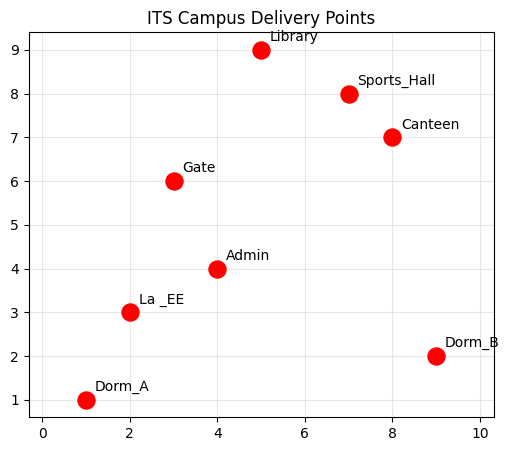

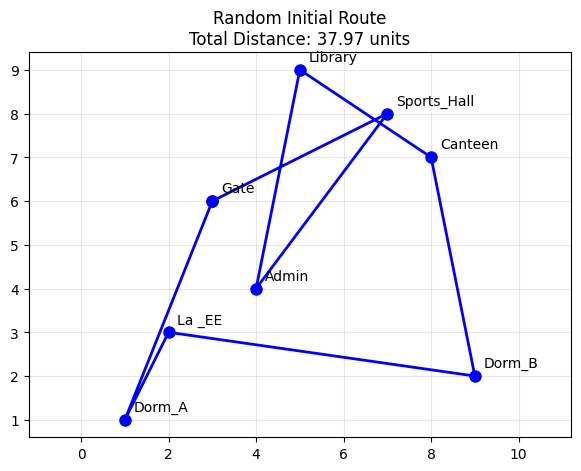

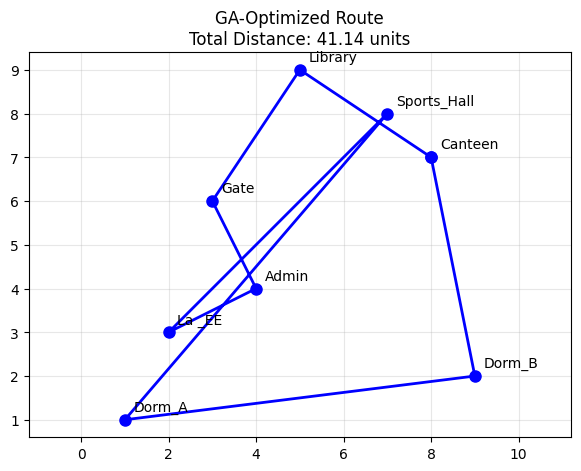

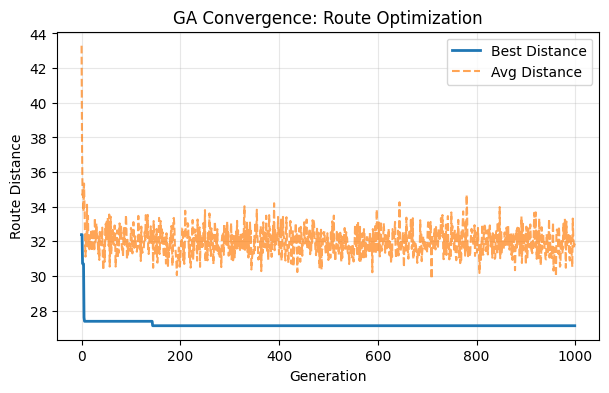

Optimized Route Order: ['Canteen', 'Library', 'Gate', 'Admin', 'La _EE', 'Sports_Hall', 'Dorm_A', 'Dorm_B']
Total Distance: 41.14 units


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# The problem: the Campus Map & Distance Matrix
names = ['Canteen', 'La _EE', 'Library', 'Dorm_A', 'Dorm_B', 'Admin', 'Sports_Hall', 'Gate']
coords = np.array([
    [8, 7], [2, 3], [5, 9], [1, 1], [9, 2], [4, 4], [7, 8], [3, 6]
])
n = len(names)
def get_dist_matrix(coords):
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist
dist_matrix = get_dist_matrix(coords)
# Plot initial map
plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c='red', s=150, zorder=5)
for i, name in enumerate(names):
    plt.annotate(name, (coords[i, 0]+0.2, coords[i, 1]+0.2), fontsize=10)
plt.title("ITS Campus Delivery Points")
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


# GA Operators for Permutation Encoding
def route_distance(route, dist_matrix):
    total = sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))
    total += dist_matrix[route[-1]][route[0]]  # return to start
    return total
def fitness(route, dist_matrix):
    return 1 / (route_distance(route, dist_matrix) + 1e-6)  # avoid div by zero
def tournament_selection(pop, fits, k=20):
    idx = np.random.choice(len(pop), k, replace=False)
    return pop[idx[np.argmax(fits[idx])]].copy()
def order_crossover(p1, p2):
    size = len(p1)
    start, end = sorted(np.random.choice(size, 2, replace=False)) #random length to cross
    child = [-1] * size
    child[start:end+1] = p1[start:end+1]
    p2_order = [g for g in p2 if g not in child[start:end+1]]
    idx = (end + 1) % size
    for gene in p2_order:
        child[idx] = gene
        idx = (idx + 1) % size
    return np.array(child)
def swap_mutation(route, rate=0.1):
    for i in range(len(route)):
        if np.random.random() < rate:
            j = np.random.randint(0, len(route))
            route[i], route[j] = route[j], route[i]
    return route


# Evolution Loop
def run_ga_tsp(pop_size=60, gens=1000, cx_rate=0.3, mut_rate=0.1):
    pop = np.array([np.random.permutation(n) for _ in range(pop_size)])
    best_dist_hist, avg_dist_hist = [], []
    for gen in range(gens):
        fits = np.array([fitness(r, dist_matrix) for r in pop])
        best_dist_hist.append(1 / np.max(fits))
        avg_dist_hist.append(1 / np.mean(fits))
        new_pop = []
        for _ in range(pop_size):
            p1 = tournament_selection(pop, fits)
            p2 = tournament_selection(pop, fits)
            child = order_crossover(p1, p2) if np.random.random() < cx_rate else p1.copy()
            child = swap_mutation(child, mut_rate)
            new_pop.append(child)
        pop = np.array(new_pop)
    best_route = pop[np.argmax(fitness(pop[np.argmax([fitness(r, dist_matrix) for r in pop])], dist_matrix))]
    return best_route, best_dist_hist, avg_dist_hist

# Run GA
best_route, best_hist, avg_hist = run_ga_tsp()
# Visualize Results
def plot_route(route, title="Delivery Route"):
    pts = coords[route]
    pts = np.vstack([pts, pts[0]])  # close loop
    plt.figure(figsize=(7, 5))
    plt.plot(pts[:, 0], pts[:, 1], 'b-o', linewidth=2, markersize=8)
    for i, name in enumerate(names):
        plt.annotate(name, (coords[i, 0]+0.2, coords[i, 1]+0.2), fontsize=10)
    plt.title(f"{title}\nTotal Distance: {route_distance(route, dist_matrix):.2f} units")
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Before (random) vs After (GA)
plot_route(np.random.permutation(n), "Random Initial Route")
plot_route(best_route, "GA-Optimized Route")
# Convergence plot
plt.figure(figsize=(7, 4))
plt.plot(best_hist, label="Best Distance", linewidth=2)
plt.plot(avg_hist, label="Avg Distance", linestyle='--', alpha=0.7)
plt.xlabel("Generation")
plt.ylabel("Route Distance")
plt.title("GA Convergence: Route Optimization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Optimized Route Order: {[names[i] for i in best_route]}")
print(f"Total Distance: {route_distance(best_route, dist_matrix):.2f} units")